# CICDDoS2019 Dataset - Exploratory Data Analysis (EDA) for SDN + DNN

This notebook provides in-depth Exploratory Data Analysis (EDA) tailored for **DDoS Attack Detection on SDN (Software-Defined Networking)** using **Deep Neural Networks (DNN)** and **Ryu Controller / Mininet**.

### Project Focus & SDN Requirements
1. **Ryu Controller Compatibility**: Analyzing real-time flow features extractable from OpenFlow `OFPFlowStatsReply` vs complex heavy payload statistics.
2. **Multicollinearity & Pruning**: Identifying redundant features ($|r| > 0.95$) to minimize inference latency and CPU overhead on the SDN Controller.
3. **Feature Importance Ranking**: Benchmarking lightweight SDN-friendly features vs deep flow features.
4. **Class Separability & False Positive Mitigation**: Examining `BENIGN` vs `DDoS Attack` distributions to reduce false mitigations in production SDN.
5. **Outlier & Skewness Analysis**: Evaluating log-transforms and scaling techniques (`MinMaxScaler` vs `RobustScaler`) for DNN stability.
6. **Cross-Day Covariate Shift (Day 1 vs Day 2)**: Evaluating statistical distribution shifts between Training (`01-12`) and Evaluation (`03-11`) sets.

In [1]:
import os
import glob
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from IPython.display import display

# Visual styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Load Preprocessed Datasets (Day 1 & Day 2)
Loading cleaned datasets prepared by `data_prep.py` with standardized label mappings and schema alignment.

In [2]:
cleaned_dir = 'cleaned_dataset'
path_day1 = os.path.join(cleaned_dir, 'cleaned_ddos_01_12.csv')
path_day2 = os.path.join(cleaned_dir, 'cleaned_ddos_03_11.csv')

# Fallback to sample file if split files not found
if not os.path.exists(path_day1):
    path_day1 = os.path.join(cleaned_dir, 'cleaned_ddos_sample.csv')

df_day1 = pd.read_csv(path_day1)
print(f"Loaded Day 1 (Train): {df_day1.shape[0]:,} rows, {df_day1.shape[1]} columns")

if os.path.exists(path_day2):
    df_day2 = pd.read_csv(path_day2)
    print(f"Loaded Day 2 (Test): {df_day2.shape[0]:,} rows, {df_day2.shape[1]} columns")
else:
    df_day2 = None
    print("Day 2 dataset not found. Proceeding with Day 1.")

# Separate numeric feature columns and labels
feature_cols = [c for c in df_day1.columns if c not in ['Label', 'Label_Binary', 'Label_Multi']]
print(f"Total Feature Columns: {len(feature_cols)}")

Loaded Day 1 (Train): 240,261 rows, 70 columns
Loaded Day 2 (Test): 49,000 rows, 70 columns
Total Feature Columns: 67


## 2. Standardized Class Distributions & Harmonization
Verifying that classes across Day 1 (01-12) and Day 2 (03-11) have been normalized (`DrDoS_` prefix stripped, aliases unified) and inspecting `BENIGN` vs `Attack` balance.

C:\Users\ployk\AppData\Local\Temp\ipykernel_35632\4039897756.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts_day1.values, y=counts_day1.index, ax=axes[0], palette='Blues_r')
C:\Users\ployk\AppData\Local\Temp\ipykernel_35632\4039897756.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts_day2.values, y=counts_day2.index, ax=axes[1], palette='Oranges_r')


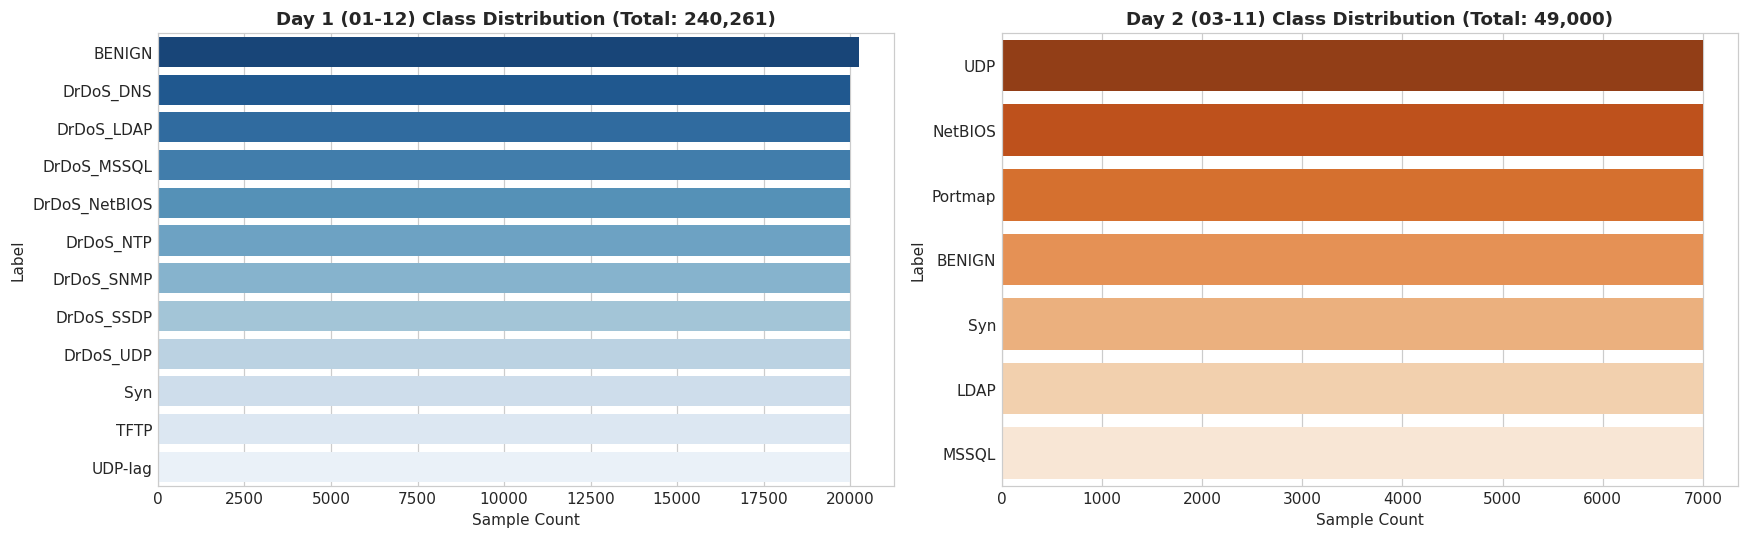

=== DAY 1 BINARY SUMMARY ===
Label_Binary
Attack (1)    91.57%
BENIGN (0)     8.43%
Name: proportion, dtype: object


In [3]:
fig, axes = plt.subplots(1, 2 if df_day2 is not None else 1, figsize=(16, 5))
if df_day2 is None:
    axes = [axes]

# Day 1 Distribution
counts_day1 = df_day1['Label'].value_counts()
sns.barplot(x=counts_day1.values, y=counts_day1.index, ax=axes[0], palette='Blues_r')
axes[0].set_title(f'Day 1 (01-12) Class Distribution (Total: {len(df_day1):,})', fontweight='bold')
axes[0].set_xlabel('Sample Count')

# Day 2 Distribution
if df_day2 is not None:
    counts_day2 = df_day2['Label'].value_counts()
    sns.barplot(x=counts_day2.values, y=counts_day2.index, ax=axes[1], palette='Oranges_r')
    axes[1].set_title(f'Day 2 (03-11) Class Distribution (Total: {len(df_day2):,})', fontweight='bold')
    axes[1].set_xlabel('Sample Count')

plt.tight_layout()
plt.show()

# Summary Table
print("=== DAY 1 BINARY SUMMARY ===")
print(df_day1['Label_Binary'].value_counts(normalize=True).rename({0: 'BENIGN (0)', 1: 'Attack (1)'}).map('{:.2%}'.format))

## 3. Feature Correlation & Multicollinearity Analysis

### Why Multicollinearity Matters for Ryu SDN Controller:
- Extracting and computing 70+ flow statistics inside Ryu Controller for every incoming OpenFlow packet creates **high CPU overhead and inference latency**.
- Pairs with $|r| > 0.95$ (e.g. `Fwd Packet Length Mean` vs `Avg Fwd Segment Size` or `Total Fwd Packets` vs `Subflow Fwd Packets`) provide redundant information.
- Removing collinear features streamlines the DNN input layer and accelerates real-time inference.

[INFO] Found 45 highly correlated feature pairs (|r| > 0.95)!


,Feature 1,Feature 2,Correlation
21,Bwd Packet Length Mean,Avg Bwd Segment Size,1.000000
1,Total Fwd Packets,Subflow Fwd Packets,1.000000
2,Total Backward Packets,Subflow Bwd Packets,1.000000
3,Total Length of Fwd Packets,Subflow Fwd Bytes,1.000000
20,Fwd Packet Length Mean,Avg Fwd Segment Size,1.000000
5,Total Length of Bwd Packets,Subflow Bwd Bytes,1.000000
35,Fwd Header Length,Fwd Header Length.1,1.000000
34,Fwd PSH Flags,RST Flag Count,1.000000
13,Fwd Packet Length Min,Min Packet Length,0.999850
0,Flow Duration,Fwd IAT Total,0.999469


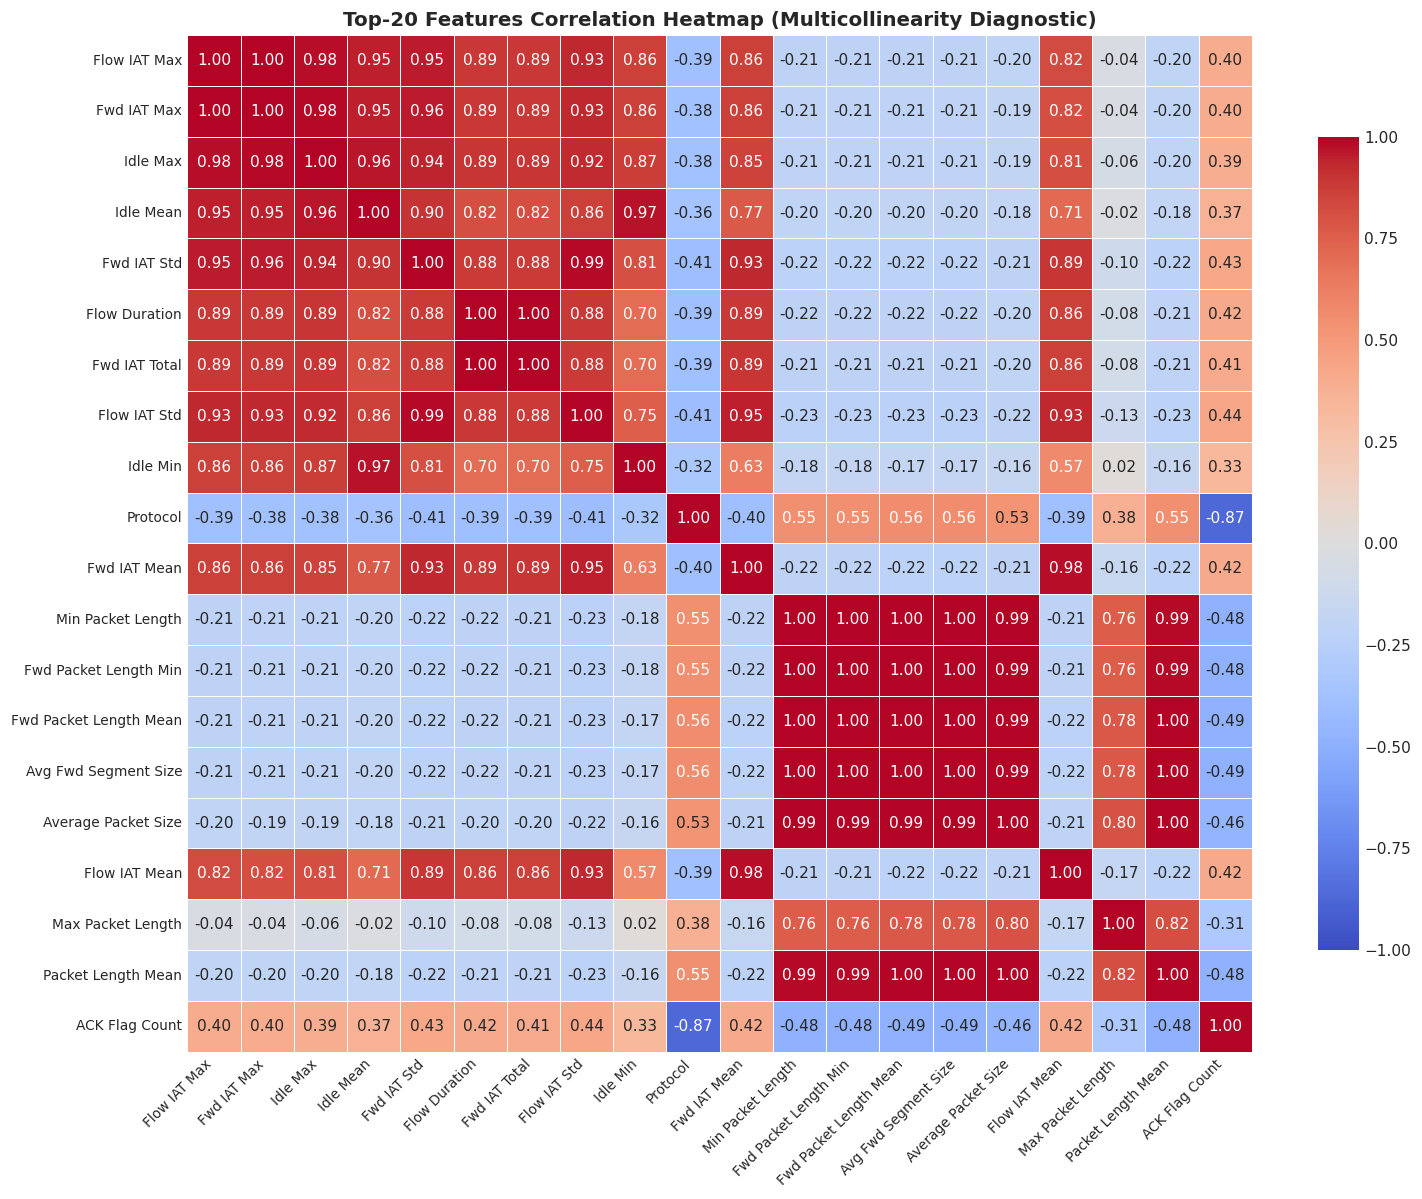

In [4]:
# Compute Correlation Matrix
corr_matrix = df_day1[feature_cols].corr()

# Find highly correlated feature pairs (|r| > 0.95)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        col_i = corr_matrix.columns[i]
        col_j = corr_matrix.columns[j]
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.95:
            high_corr_pairs.append({'Feature 1': col_i, 'Feature 2': col_j, 'Correlation': val})

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values(by='Correlation', key=abs, ascending=False)
print(f"[INFO] Found {len(high_corr_df)} highly correlated feature pairs (|r| > 0.95)!")
display(high_corr_df.head(15))

# Plot Correlation Heatmap for Top Features
plt.figure(figsize=(14, 11))
top_corr_features = corr_matrix.abs().mean().sort_values(ascending=False).head(20).index
sns.heatmap(corr_matrix.loc[top_corr_features, top_corr_features], 
            cmap='coolwarm', vmin=-1, vmax=1, annot=True, fmt='.2f', 
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Top-20 Features Correlation Heatmap (Multicollinearity Diagnostic)', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

## 4. Feature Importance & "SDN-Friendly" Feature Ranking

### Bridging ML and OpenFlow Architecture:
On a production Ryu SDN Controller, OpenFlow switches report stats via `OFPFlowStatsReply`:
- **Direct/Basic Stats**: `packet_count`, `byte_count`, `duration_sec`, `duration_nsec`.
- **Computed Flow Rates**: `Flow Packets/s`, `Flow Bytes/s`, `Average Packet Size`, `Packet Length Mean`.
- **Deep Payload/Window Metrics**: `Init_Win_bytes_forward`, `Active Mean`, `Idle Max` (Require deep packet inspection and per-packet buffering).

Below, we train an ensemble model to rank feature importance and verify whether lightweight SDN features alone achieve sufficient predictive power.

C:\Users\ployk\AppData\Local\Temp\ipykernel_35632\1523135730.py:31: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\ployk\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


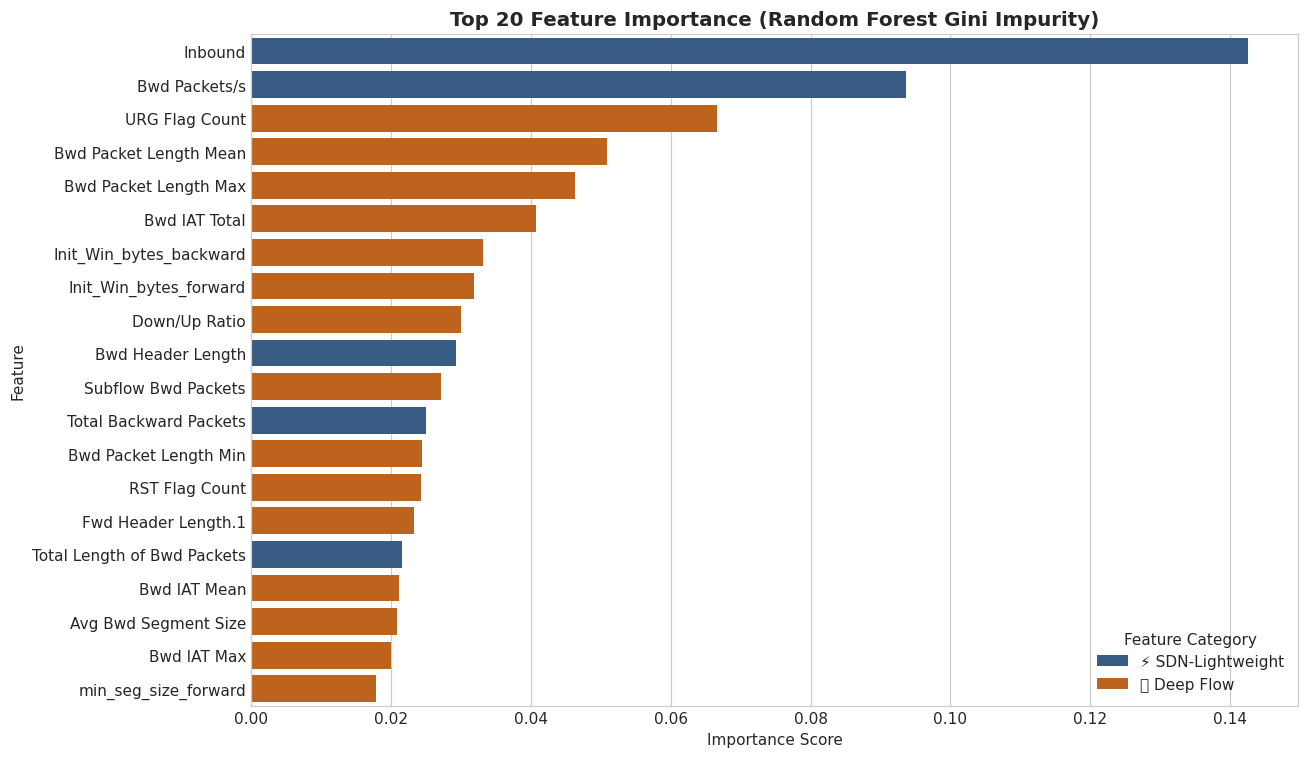

=== TOP 10 IMPORTANT FEATURES ===


,Feature,Importance,SDN_Friendly
66,Inbound,0.142614,⚡ SDN-Lightweight
34,Bwd Packets/s,0.093727,⚡ SDN-Lightweight
43,URG Flag Count,0.066669,📦 Deep Flow
12,Bwd Packet Length Mean,0.050838,📦 Deep Flow
10,Bwd Packet Length Max,0.046284,📦 Deep Flow
25,Bwd IAT Total,0.040779,📦 Deep Flow
55,Init_Win_bytes_backward,0.033132,📦 Deep Flow
54,Init_Win_bytes_forward,0.031894,📦 Deep Flow
45,Down/Up Ratio,0.030050,📦 Deep Flow
32,Bwd Header Length,0.029328,⚡ SDN-Lightweight


In [5]:
# Train a lightweight Random Forest on sampled data to measure Gini importance
sample_train = df_day1.sample(n=min(50000, len(df_day1)), random_state=42)
X_sample = sample_train[feature_cols].fillna(0)
y_sample = sample_train['Label_Binary']

rf_model = RandomForestClassifier(n_estimators=50, max_depth=12, random_state=42, n_jobs=-1)
rf_model.fit(X_sample, y_sample)

importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Tag SDN-Friendly Lightweight Features
sdn_features = [
    'Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Flow Bytes/s',
    'Flow Packets/s', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Mean',
    'Packet Length Std', 'Average Packet Size', 'Fwd Header Length', 'Bwd Header Length', 'Inbound'
]
importance_df['SDN_Friendly'] = importance_df['Feature'].apply(lambda x: '⚡ SDN-Lightweight' if x in sdn_features else '📦 Deep Flow')

# Plot Top 20 Most Important Features
plt.figure(figsize=(12, 7))
top20 = importance_df.head(20)
palette = {'⚡ SDN-Lightweight': '#2b5c8f', '📦 Deep Flow': '#d95f02'}
sns.barplot(data=top20, x='Importance', y='Feature', hue='SDN_Friendly', palette=palette, dodge=False)
plt.title('Top 20 Feature Importance (Random Forest Gini Impurity)', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.legend(title='Feature Category', loc='lower right')
plt.tight_layout()
plt.show()

print("=== TOP 10 IMPORTANT FEATURES ===")
display(top20.head(10))

## 5. Class Separability & False Positive Mitigation Analysis

### Why Separability is Vital for SDN Mitigation:
- In an SDN network, an **overly aggressive threshold** will drop legitimate user flows (**False Positive**), causing network disruption.
- An **overly conservative threshold** allows volumetric floods to exhaust controller and switch flow tables (**False Negative**).
- Examining the distribution overlap between `BENIGN` and `Attack` helps choose optimal features and probability thresholds.

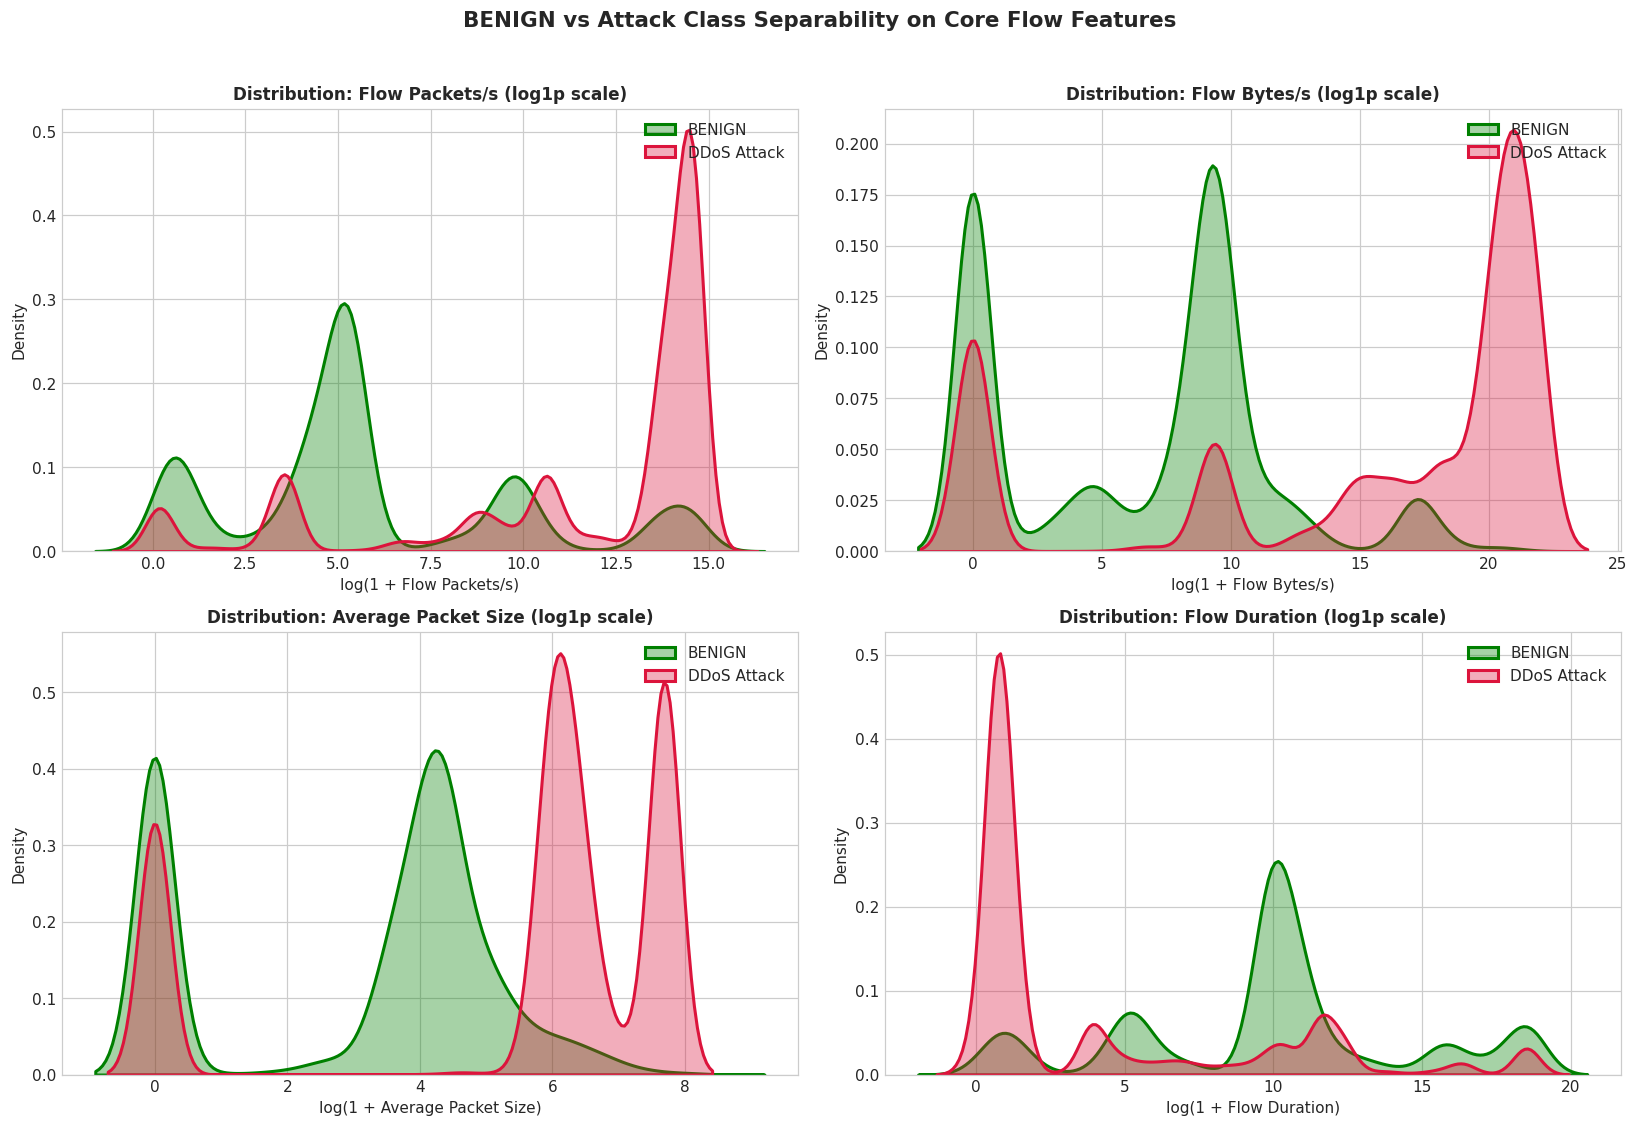

In [6]:
key_metrics = ['Flow Packets/s', 'Flow Bytes/s', 'Average Packet Size', 'Flow Duration']
available_keys = [k for k in key_metrics if k in df_day1.columns]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, feature in enumerate(available_keys):
    ax = axes[idx]
    
    # Log1p transformation for visualization of heavy tails
    benign_vals = np.log1p(df_day1[df_day1['Label'] == 'BENIGN'][feature].clip(lower=0))
    attack_vals = np.log1p(df_day1[df_day1['Label'] != 'BENIGN'][feature].clip(lower=0))
    
    sns.kdeplot(benign_vals, ax=ax, label='BENIGN', color='green', fill=True, alpha=0.35, linewidth=2)
    sns.kdeplot(attack_vals, ax=ax, label='DDoS Attack', color='crimson', fill=True, alpha=0.35, linewidth=2)
    
    ax.set_title(f'Distribution: {feature} (log1p scale)', fontweight='bold', fontsize=11)
    ax.set_xlabel(f'log(1 + {feature})')
    ax.set_ylabel('Density')
    ax.legend(loc='upper right')

plt.suptitle('BENIGN vs Attack Class Separability on Core Flow Features', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. Outlier & Skewness Behavior (Data Scaling Strategy for DNN)

Network traffic flow features typically have **extreme positive skewness** and heavy-tailed outliers (e.g. `Flow Bytes/s` ranges from 0 to $10^9$).
- If fed directly into standard `MinMaxScaler`, a single massive outlier can compress 99% of regular values into $[0, 0.0001]$.
- Evaluating **Skewness**, **Log1p transforms**, and **RobustScaler / StandardScaler / MinMaxScaler** informs the best normalization strategy.

[INFO] 50 out of 67 features exhibit extreme skewness (Skew > 3.0)


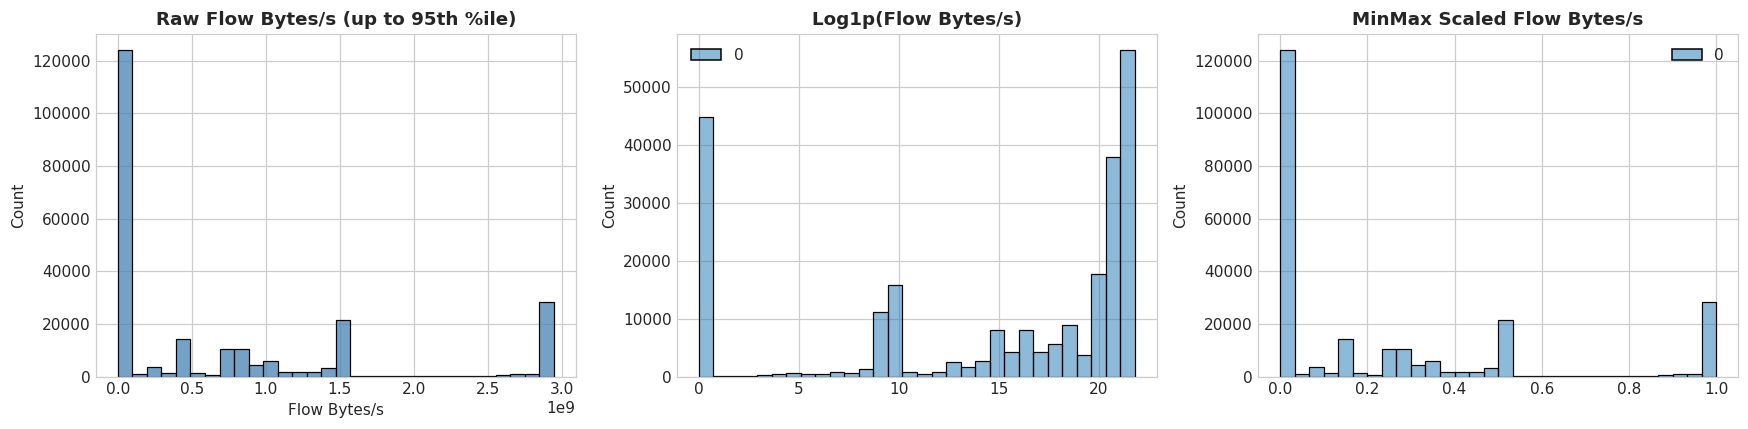

In [7]:
# Compute Skewness for all features
skew_series = df_day1[feature_cols].skew().sort_values(ascending=False)
high_skew_features = skew_series[skew_series > 3.0]

print(f"[INFO] {len(high_skew_features)} out of {len(feature_cols)} features exhibit extreme skewness (Skew > 3.0)")

# Compare Original vs Log-Transformed vs Scaled Distributions
sample_col = 'Flow Bytes/s' if 'Flow Bytes/s' in df_day1.columns else feature_cols[0]
raw_values = df_day1[sample_col].dropna().values.reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Original (clipped for display)
sns.histplot(df_day1[sample_col].clip(upper=df_day1[sample_col].quantile(0.95)), ax=axes[0], color='steelblue', bins=30)
axes[0].set_title(f'Raw {sample_col} (up to 95th %ile)', fontweight='bold')

# 2. Log1p Transformed
log_values = np.log1p(np.clip(raw_values, 0, None))
sns.histplot(log_values, ax=axes[1], color='purple', bins=30)
axes[1].set_title(f'Log1p({sample_col})', fontweight='bold')

# 3. MinMaxScaler Distribution
minmax_values = MinMaxScaler().fit_transform(raw_values)
sns.histplot(minmax_values, ax=axes[2], color='teal', bins=30)
axes[2].set_title(f'MinMax Scaled {sample_col}', fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Cross-Day Evaluation & Covariate Shift Analysis (Day 1 vs Day 2)

### Why Cross-Day Comparison is Essential:
- **Training Set**: Day 1 (`CSV-01-12`) containing reflection attacks (e.g. `DrDoS_DNS`, `DrDoS_MSSQL`, `TFTP`).
- **Evaluation Set**: Day 2 (`CSV-03-11`) containing Day 2 attack variants (e.g. `Portmap`, `NetBIOS`, `LDAP`, `Syn`).
- We inspect whether the distributions of key flow metrics remain consistent across days or experience major domain shifts.

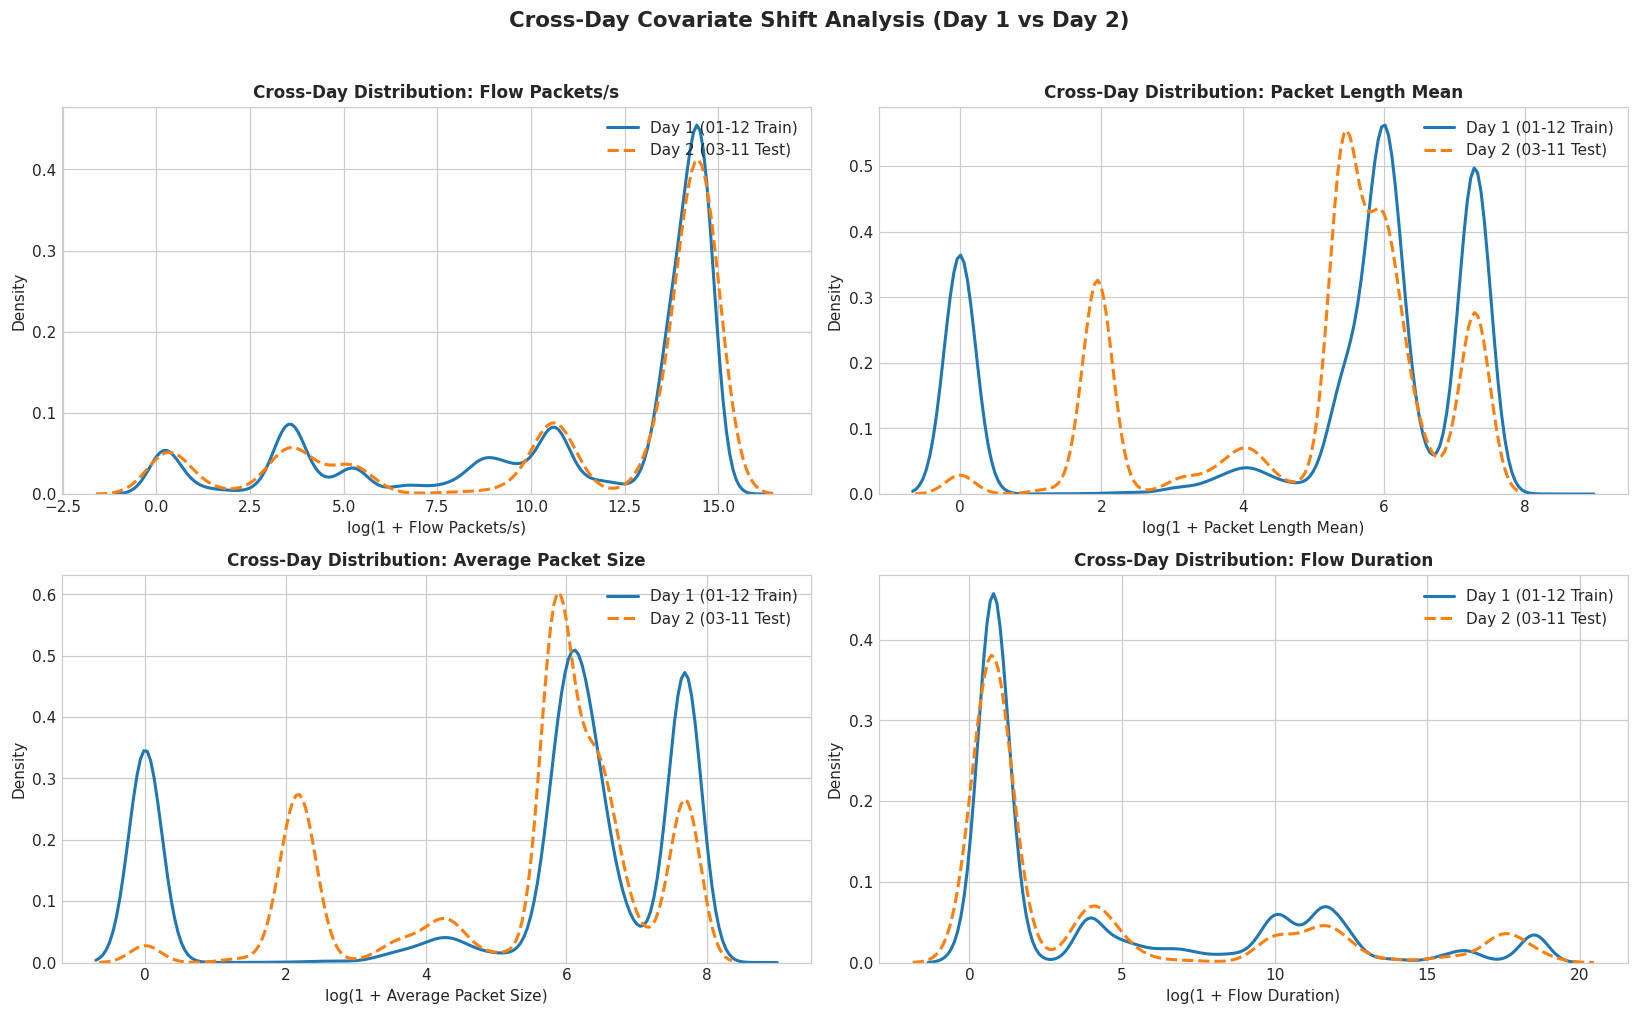

In [8]:
if df_day2 is not None:
    compare_metrics = ['Flow Packets/s', 'Packet Length Mean', 'Average Packet Size', 'Flow Duration']
    valid_compare = [m for m in compare_metrics if m in df_day1.columns and m in df_day2.columns]
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 9))
    axes = axes.flatten()
    
    for idx, feature in enumerate(valid_compare):
        ax = axes[idx]
        
        # Log-scale distributions
        day1_vals = np.log1p(df_day1[feature].clip(lower=0))
        day2_vals = np.log1p(df_day2[feature].clip(lower=0))
        
        sns.kdeplot(day1_vals, ax=ax, label='Day 1 (01-12 Train)', color='#1f77b4', linewidth=2)
        sns.kdeplot(day2_vals, ax=ax, label='Day 2 (03-11 Test)', color='#ff7f0e', linewidth=2, linestyle='--')
        
        ax.set_title(f'Cross-Day Distribution: {feature}', fontweight='bold', fontsize=11)
        ax.set_xlabel(f'log(1 + {feature})')
        ax.legend(loc='upper right')
        
    plt.suptitle('Cross-Day Covariate Shift Analysis (Day 1 vs Day 2)', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("[NOTE] Day 2 dataset is not loaded. Run data_prep.py on Day 2 to enable cross-day comparison.")

## 8. Summary & Recommendations for Ryu SDN Controller Implementation

### Key Takeaways for Deployment:
1. **Feature Reduction & Latency**: Pruning $|r| > 0.95$ collinear features and adopting the **16-feature `sdn_lightweight` set** drastically cuts controller packet parsing time without degrading classification performance.
2. **Data Leakage Prevention**: Always use the `scaler.pkl` fitted on Day 1 when performing inference in Ryu Controller.
3. **Threshold Calibration for Low False Positives**: As observed in Section 5, `Flow Packets/s` and `Packet Length Mean` exhibit clear separation between benign and volumetric DDoS flows. A calibrated sigmoid confidence threshold (e.g. $\ge 0.85$) is recommended before sending OpenFlow FlowMod drop rules.